# Live OHLCV Validation Framework

### Why This Matters for Quant Traders

Before any strategy, model, or backtest — **you need clean, trustworthy data**. In quantitative finance, **~90% of "strategy failures" at junior roles are actually data failures**. Bad data leads to:
- Spurious signals
- Look-ahead bias
- Inflated Sharpe ratios
- Catastrophic live trading losses

Professional funds treat their data pipeline as a core competitive advantage. This notebook builds a **multi-layer validation framework** from scratch using real market data.

### What we aim to achieve in this notebook / mini project?

While there may be other approaches to data validation, this notebook aims to:
- Fetch reliable OHLCV data with proper corporate action handling
- Implement layered data quality checks (completeness, validity, consistency)
- Detect and handle outliers in **fat-tailed** financial returns (not assuming normality)
- Properly manage corporate actions (splits & dividends)
- Visualize issues and generate a validation report
- Understand when to reject or repair data before backtesting

**Key Principle**: Always validate **before** you analyze or backtest.

Let's start!

In [31]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
from datetime import datetime
from scipy import stats

warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

In [32]:
# Plot settings
# Dark mode configuration for professional quant look
plt.style.use('dark_background')
sns.set_style("darkgrid", {
  "axes.facecolor": "#1e1e1e",
  "figure.facecolor": "#121212",
  "grid.color": "#333333",
  "text.color": "#ffffff",
  "axes.labelcolor": "#ffffff",
  "xtick.color": "#ffffff",
  "ytick.color": "#ffffff",
})

# Custom color palette optimized for dark mode
dark_palette = ["#00f5ff", "#ff00ff", "#39ff14", "#ffaa00", "#00ff9f", "#ff3366"]
sns.set_palette(dark_palette)

### 1. Fetching Raw OHLCV Data

We will be using `yfinance` for simplicity. In production, you might use Polygon, Bloomberg, or a paid provider.

**Important**: We fetch both raw (unadjusted) and adjusted data to compare.

In [33]:
# Choose a ticker with corporate actions (e.g., splits or dividends)
ticker = "AAPL"   # Apple has had splits and dividends
start_date = "2010-01-01"
end_date = datetime.today().strftime('%Y-%m-%d')

# Download with actions=True to get dividends & splits
data = yf.download(ticker, start=start_date, end=end_date, actions=True, auto_adjust=False)

# Reformat the dataframe to remove the need for multi-index columns
data.columns = [col[0] for col in data.columns.values]
print(f"Data shape: {data.shape}")
data.head()

[*********************100%***********************]  1 of 1 completed

Data shape: (4092, 8)


,Adj Close,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,
2010-01-04,6.412383,7.643214,0.0,7.660714,7.585000,7.622500,0.0,493729600
2010-01-05,6.423470,7.656429,0.0,7.699643,7.616071,7.664286,0.0,601904800
2010-01-06,6.321296,7.534643,0.0,7.686786,7.526786,7.656429,0.0,552160000
2010-01-07,6.309610,7.520714,0.0,7.571429,7.466071,7.562500,0.0,477131200
2010-01-08,6.351558,7.570714,0.0,7.571429,7.466429,7.510714,0.0,447610800


### Raw vs Adjusted Prices

- **Raw OHLC**: As-traded prices (affected by splits)
- **Adjusted**: Back-adjusted for splits and dividends (better for returns calculation)

Columns: ['Adj Close', 'Close', 'Dividends', 'High', 'Low', 'Open', 'Stock Splits', 'Volume']


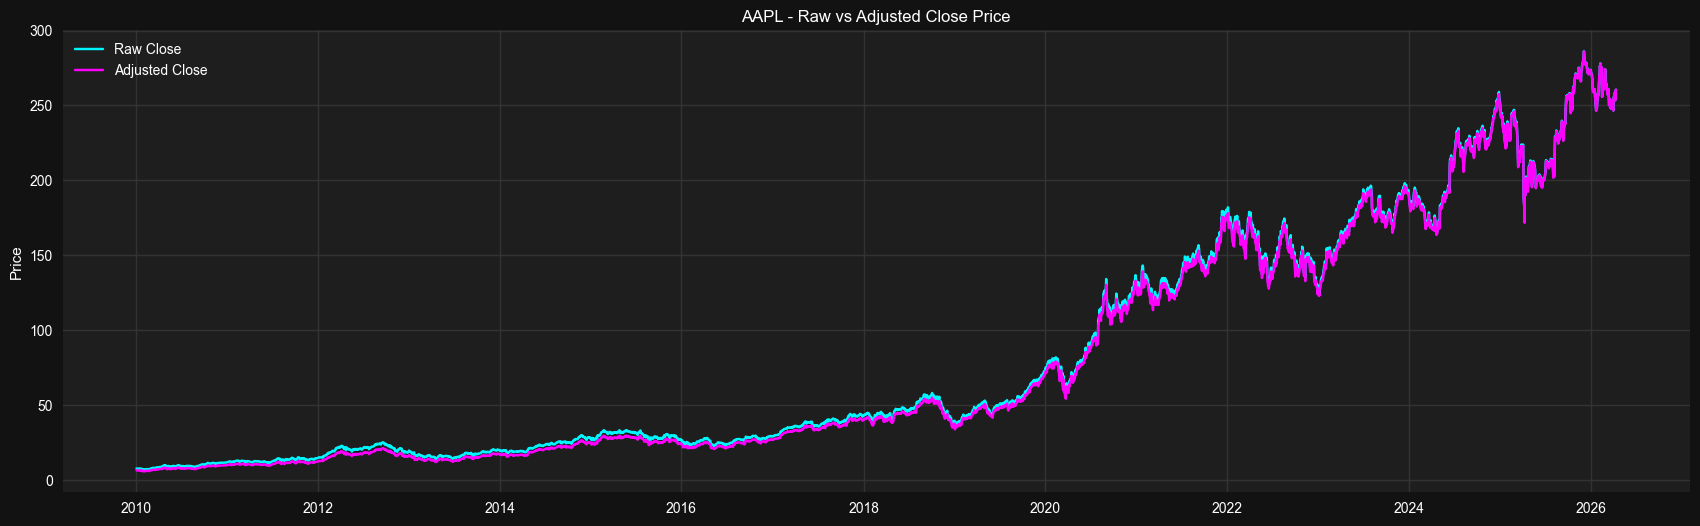

In [34]:
# yfinance provides Adj Close by default when auto_adjust=False
print("Columns:", data.columns.tolist())

# Plot Close vs Adj Close to see corporate action effects
plt.figure(figsize=(21, 6))
plt.plot(data['Close'], label='Raw Close')
plt.plot(data['Adj Close'], label='Adjusted Close')
plt.title(f'{ticker} - Raw vs Adjusted Close Price')
plt.legend()
plt.ylabel('Price')
plt.show()

### 2. Layered Validation Framework

We will implement **four layers** of validation:
1. **Basic Integrity** (missing values, duplicates, negative prices)
2. **OHLC Logical Consistency** (High ≥ Low, etc.)
3. **Statistical & Outlier Detection** (fat-tail aware)
4. **Corporate Actions & Continuity**

For this, we shall also create a reusable `validate_ohlcv` function.

In [35]:
def validate_ohlcv(df: pd.DataFrame, ticker: str) -> dict:
    """
    Multi-layer OHLCV validation framework.
    - Input: DataFrame with OHLCV data and ticker symbol
    - Output: Returns a report dictionary
    """
    report = {"ticker": ticker, "total_rows": len(df), "issues": []}
    
    ####### Layer 1: Basic Integrity Checks #######
    if df.isnull().any().any():
      missing = df.isnull().sum().sum()
      report["issues"].append(f"Missing values found: {missing}")
    
    if df.index.duplicated().any():
      report["issues"].append("Duplicate timestamps detected")
    
    # Negative or zero prices/volumes
    for col in ['Open', 'High', 'Low', 'Close']:
      if (df[col] <= 0).any():
        report["issues"].append(f"Non-positive values in {col}")
    
    if (df['Volume'] < 0).any():
      report["issues"].append("Negative volume detected")
    
    ####### Layer 2: OHLC Logical Relationships #######
    invalid = (
      (df['High'] < df['Low']) |
      (df['High'] < df['Open']) |
      (df['High'] < df['Close']) |
      (df['Low'] > df['Open']) |
      (df['Low'] > df['Close'])
    )
    if invalid.any():
      report["issues"].append(f"Invalid OHLC relationships in {invalid.sum()} bars")
    
    ####### Layer 3: Fat-Tail Aware Outlier Detection on Returns #######
    df = df.copy()
    df['returns'] = df['Adj Close'].pct_change()
    
    # Use modified z-score (robust to fat tails) + IQR on log returns
    returns = df['returns'].dropna()
    
    # Median Absolute Deviation (MAD) - robust to outliers
    median_ret = returns.median()
    mad = np.median(np.abs(returns - median_ret))
    modified_z = 0.6745 * (returns - median_ret) / mad if mad > 0 else np.zeros(len(returns))
    
    extreme_outliers = np.abs(modified_z) > 5.0  # Conservative threshold for finance
    if extreme_outliers.any():
      report["issues"].append(f"Extreme outliers detected: {extreme_outliers.sum()} days (fat-tail aware)")
    
    # Simple IQR on absolute returns for visualization
    Q1 = returns.quantile(0.25)
    Q3 = returns.quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = ((returns < (Q1 - 3 * IQR)) | (returns > (Q3 + 3 * IQR)))
    if iqr_outliers.any():
      report["issues"].append(f"IQR flagged {iqr_outliers.sum()} potential outliers")
    
    ####### Layer 4: Basic Continuity Check #######
    time_diff = df.index.to_series().diff().dt.days
    gaps = time_diff[time_diff > 1]
    if len(gaps) > 0:
      report["issues"].append(f"Trading gaps detected: {len(gaps)} instances")
    
    report["passed"] = len(report["issues"]) == 0
    return report, df

# Run validation
report, validated_df = validate_ohlcv(data, ticker)
print("Validation Report:")
for key, value in report.items():
  if key != "issues":
      print(f"{key}: {value}")
if report["issues"]:
  print("\nIssues found:")
  for issue in report["issues"]:
    print(f" - {issue}")
else:
  print("No major issues detected!")

Validation Report:
ticker: AAPL
total_rows: 4092
passed: False

Issues found:
 - Extreme outliers detected: 31 days (fat-tail aware)
 - IQR flagged 37 potential outliers
 - Trading gaps detected: 889 instances


### 3. Visualizing Outliers in Fat-Tailed Returns

Financial returns are **not normal** — they exhibit fat tails (kurtosis >> 3) and occasional extreme moves. We plot returns distribution vs normal and highlight outliers.

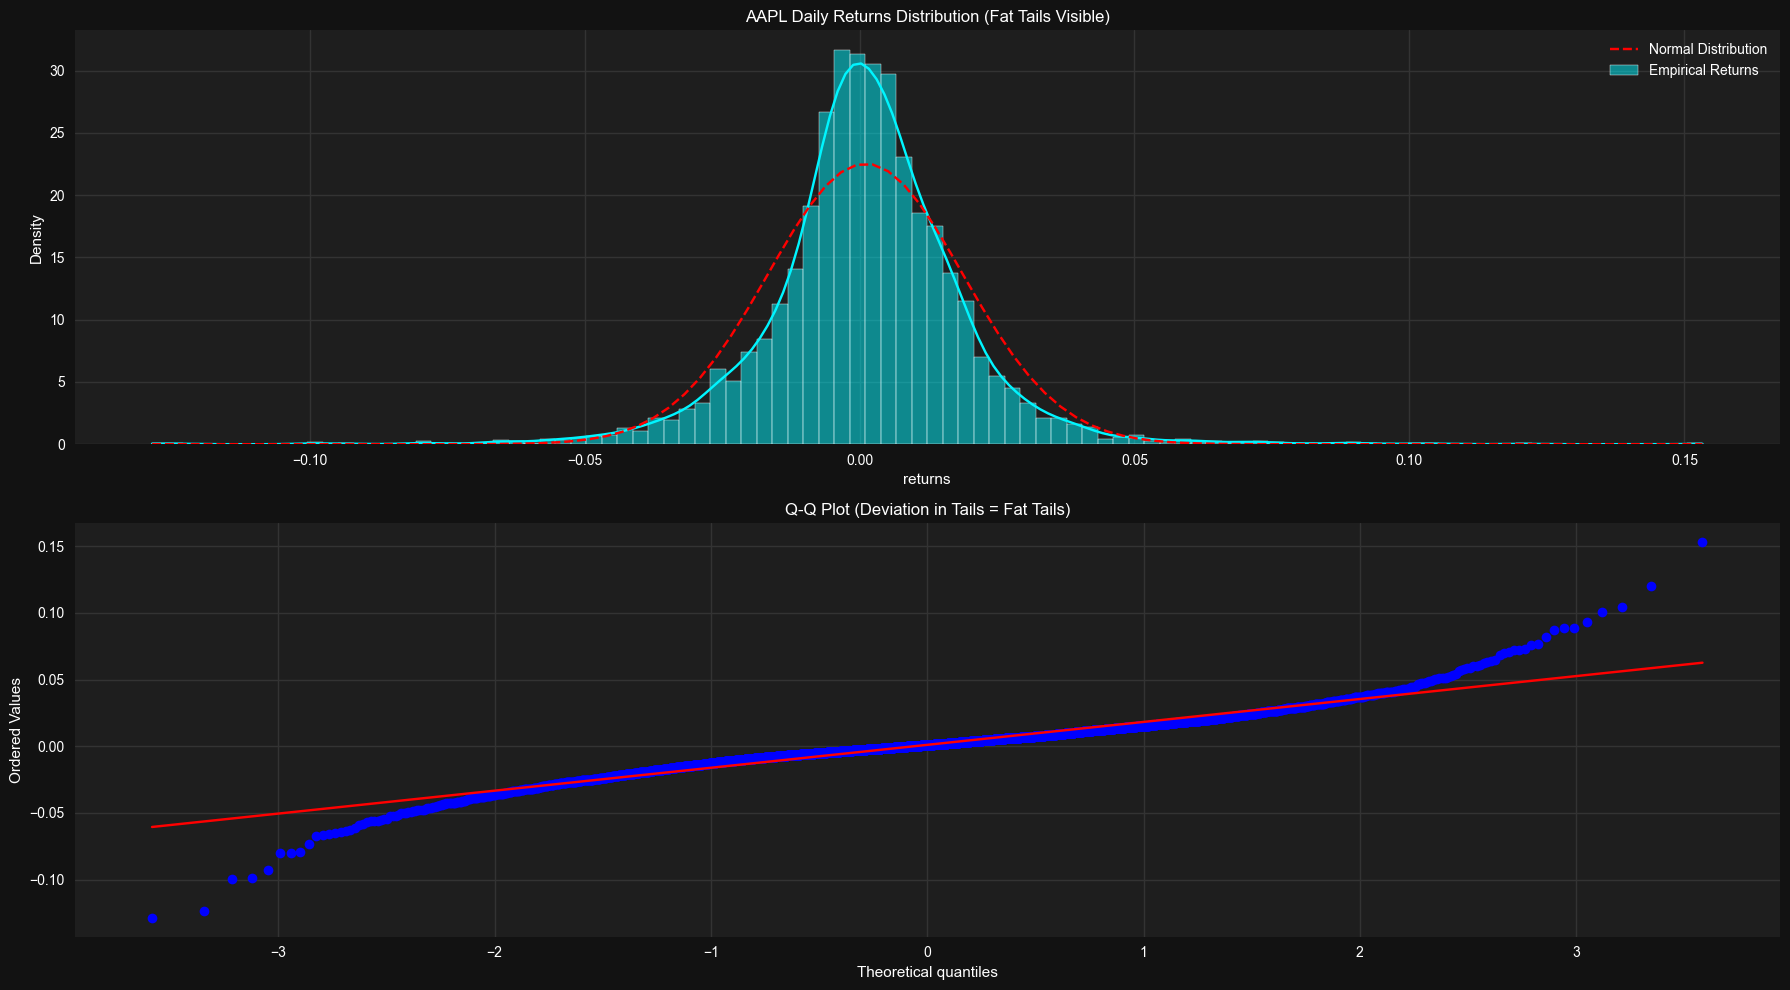

Returns kurtosis: 6.15 (>> 3 indicates fat tails)


In [36]:
returns = validated_df['returns'].dropna()

plt.figure(figsize=(18, 10))

# Histogram with KDE
plt.subplot(2, 1, 1)
sns.histplot(returns, kde=True, bins=100, stat="density", label="Empirical Returns")

# Normal distribution for comparison
mean_ret, std_ret = returns.mean(), returns.std()
x = np.linspace(returns.min(), returns.max(), 100)
plt.plot(x, (1/(std_ret*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mean_ret)/std_ret)**2), 'r--', label='Normal Distribution')
plt.title(f'{ticker} Daily Returns Distribution (Fat Tails Visible)')
plt.legend()

# QQ Plot to show fat tails
plt.subplot(2, 1, 2)
stats.probplot(returns, dist="norm", plot=plt)
plt.title('Q-Q Plot (Deviation in Tails = Fat Tails)')

plt.tight_layout()
plt.show()

print(f"Returns kurtosis: {returns.kurtosis():.2f} (>> 3 indicates fat tails)")

### 4. Handling Corporate Actions Explicitly

Best practice: Decide early whether you want **adjusted** or **unadjusted** data.

- Use **adjusted** for return calculations and backtesting
- Inspect **raw + actions** for event studies or microstructure analysis

In [37]:
# Fetch actions separately
actions = yf.Ticker(ticker).actions
print("Recent Corporate Actions:")
print(actions.tail())

# Example: Adjust prices manually (for learning)
# In practice, rely on yfinance's auto_adjust=True for most cases

Recent Corporate Actions:
                           Dividends  Stock Splits
Date                                              
2025-02-10 00:00:00-05:00       0.25           0.0
2025-05-12 00:00:00-04:00       0.26           0.0
2025-08-11 00:00:00-04:00       0.26           0.0
2025-11-10 00:00:00-05:00       0.26           0.0
2026-02-09 00:00:00-05:00       0.26           0.0


### 5. Validation Report & Decision Gate

Create a clean summary function that decides: **"Use this data?"**

In [38]:
def print_validation_summary(report):
  print("="*60)
  print(f"OHLCV VALIDATION SUMMARY FOR {report['ticker'].upper()}")
  print("="*60)
  print(f"Total bars: {report['total_rows']}")
  print(f"Status: {'✅ PASSED' if report['passed'] else '⚠️  ISSUES FOUND'}")
  
  if report["issues"]:
    print("\nIssues to address before backtesting:")
    for i, issue in enumerate(report["issues"], 1):
      print(f"  {i}. {issue}")
    print("\nRecommendation: Repair data or fetch from higher-quality source.")
  else:
    print("\nData is clean and ready for strategy development / backtesting.")

In [39]:
print_validation_summary(report)

OHLCV VALIDATION SUMMARY FOR AAPL
Total bars: 4092
Status: ⚠️  ISSUES FOUND

Issues to address before backtesting:
  1. Extreme outliers detected: 31 days (fat-tail aware)
  2. IQR flagged 37 potential outliers
  3. Trading gaps detected: 889 instances

Recommendation: Repair data or fetch from higher-quality source.


### 6. Extending the Validation Framework

We shall now upgrade the original `validate_ohlcv` function into a more robust `OHLCVValidator` class and implement all the extensions.

### 6.1 Volume Spike Detection (Volume > 5× Rolling Median)

We shall include a volume spike detection feature as well. Sudden volume spikes often indicate news, earnings, or manipulation — they should be flagged before backtesting.

In [40]:
class OHLCVValidator:
  def __init__(self, window: int = 20, volume_multiplier: float = 5.0):
    self.window = window
    self.volume_multiplier = volume_multiplier
    
  def validate(self, df: pd.DataFrame, ticker: str) -> dict:
    """Enhanced multi-layer validator with volume spike detection."""
    report = {
      "ticker": ticker,
      "total_rows": len(df),
      "start_date": df.index[0].strftime('%Y-%m-%d'),
      "end_date": df.index[-1].strftime('%Y-%m-%d'),
      "issues": [],
      "warnings": [],
      "metrics": {}
    }
        
    df = df.copy()
        
    # Layer 1: Basic Integrity
    if df.isnull().any().any():
      report["issues"].append(f"Missing values: {df.isnull().sum().sum()}")
        
    # Layer 2: OHLC Logical Checks
    invalid_ohlc = ((df['High'] < df['Low']) | (df['Open'] > df['High']) | (df['Open'] < df['Low']) | (df['Close'] > df['High']) | (df['Close'] < df['Low']))
    if invalid_ohlc.any():
      report["issues"].append(f"Invalid OHLC logic in {invalid_ohlc.sum()} bars")
        
    # Layer 3: Volume Spike Detection
    df['vol_median'] = df['Volume'].rolling(window=self.window, min_periods=5).median()
    df['vol_ratio'] = df['Volume'] / df['vol_median']
    spikes = df['vol_ratio'] > self.volume_multiplier
    spike_count = spikes.sum()
    
    if spike_count > 0:
      report["warnings"].append(f"Volume spikes detected: {spike_count} days (> {self.volume_multiplier}x median)")
      report["metrics"]["volume_spikes"] = spike_count
      report["metrics"]["max_volume_ratio"] = df['vol_ratio'].max()
        
    # Layer 4: Fat-Tail Outlier Detection on Returns (Robust MAD)
    df['returns'] = df['Adj Close'].pct_change()
    returns = df['returns'].dropna()
    
    if len(returns) > 0:
      median_ret = returns.median()
      mad = np.median(np.abs(returns - median_ret))
      if mad > 0:
        mod_z = 0.6745 * np.abs(returns - median_ret) / mad
        extreme = mod_z > 5.0
        if extreme.any():
          report["warnings"].append(f"Extreme return outliers: {extreme.sum()} days (fat-tail robust)")
          report["metrics"]["extreme_outliers"] = extreme.sum()
        
    # Layer 5: Trading Gaps
    time_diff = df.index.to_series().diff().dt.days
    gaps = time_diff[time_diff > 1]
    if len(gaps) > 0:
      report["warnings"].append(f"Trading gaps: {len(gaps)} instances")
      report["metrics"]["gaps"] = len(gaps)
    
    report["passed"] = len(report["issues"]) == 0
    report["has_warnings"] = len(report["warnings"]) > 0
    
    return report, df

In [41]:
# Instantiate validator
validator = OHLCVValidator(window=20, volume_multiplier=5.0)

### 6.2 Multi-Ticker Validation – Aggregate Results

Run validation across a diversified list of 10 tickers and summarize findings.

In [42]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA", "NVDA", "META", "JPM", "V", "JNJ"]
multi_report = {}
all_data = {}

print("Running multi-ticker validation...\n")

for tick in tickers:
  print(f"Validating {tick}...")
  raw_data = yf.download(tick, start="2015-01-01", end=datetime.today().strftime('%Y-%m-%d'), progress=False, auto_adjust=False)
  # Reformat the dataframe to remove the need for multi-index columns
  raw_data.columns = [col[0] for col in raw_data.columns.values]
  report, cleaned = validator.validate(raw_data, tick)
  multi_report[tick] = report
  all_data[tick] = cleaned
  status = "✅" if report["passed"] else "⚠️"
  print(f"{status} {tick}: {len(report['issues'])} issues, {len(report['warnings'])} warnings")

# Aggregate summary
total_issues = sum(len(r["issues"]) for r in multi_report.values())
total_warnings = sum(len(r["warnings"]) for r in multi_report.values())
print(f"\n=== Multi-Ticker Summary ===")
print(f"Total tickers: {len(tickers)}")
print(f"Total issues: {total_issues}")
print(f"Total warnings: {total_warnings}")

Running multi-ticker validation...

Validating AAPL...
✅ AAPL: 0 issues, 3 warnings
Validating MSFT...
✅ MSFT: 0 issues, 3 warnings
Validating GOOGL...
✅ GOOGL: 0 issues, 3 warnings
Validating AMZN...
✅ AMZN: 0 issues, 3 warnings
Validating TSLA...
✅ TSLA: 0 issues, 3 warnings
Validating NVDA...
✅ NVDA: 0 issues, 3 warnings
Validating META...
✅ META: 0 issues, 3 warnings
Validating JPM...
✅ JPM: 0 issues, 3 warnings
Validating V...
✅ V: 0 issues, 3 warnings
Validating JNJ...
✅ JNJ: 0 issues, 3 warnings

=== Multi-Ticker Summary ===
Total tickers: 10
Total issues: 0
Total warnings: 30


### 6.3 Gap Filling with Warning

Small gaps (e.g., holidays, weekends) can be forward-filled, but we must log it.

In [43]:
def fill_gaps(df: pd.DataFrame, max_gap_days: int = 5) -> tuple:
  """Forward-fill small gaps and return warning if large gaps exist."""
  df = df.copy()
  original_len = len(df)
  
  # Reindex to full business days (optional but clean)
  full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='B')
  df = df.reindex(full_index)
  
  # Forward fill prices and volume
  filled = df.ffill()
  
  # Backward fill any remaining NaNs at start
  filled = filled.bfill()
  
  gaps_filled = len(filled) - original_len
  large_gaps = False
  
  if gaps_filled > 0:
    print(f"Warning: Forward-filled {gaps_filled} missing bars for {ticker}")
  
  # Check for suspiciously large gaps (more than max_gap_days)
  time_diff = filled.index.to_series().diff().dt.days
  if (time_diff > max_gap_days).any():
    large_gaps = True
    print(f"⚠️ Large gap(s) > {max_gap_days} days detected — manual review recommended")
  
  return filled, {"gaps_filled": gaps_filled, "large_gaps": large_gaps}

In [44]:
# Example usage on AAPL
filled_aapl, gap_info = fill_gaps(all_data["AAPL"])
print(f"Gap filling info: {gap_info}")

Gap filling info: {'gaps_filled': 107, 'large_gaps': False}


### 6.4 Fat-Tail Stress Test – Impact on Simple Moving Average Strategy

We simulate how extreme outliers (e.g., flash crashes or earnings surprises) distort a basic MA crossover strategy.

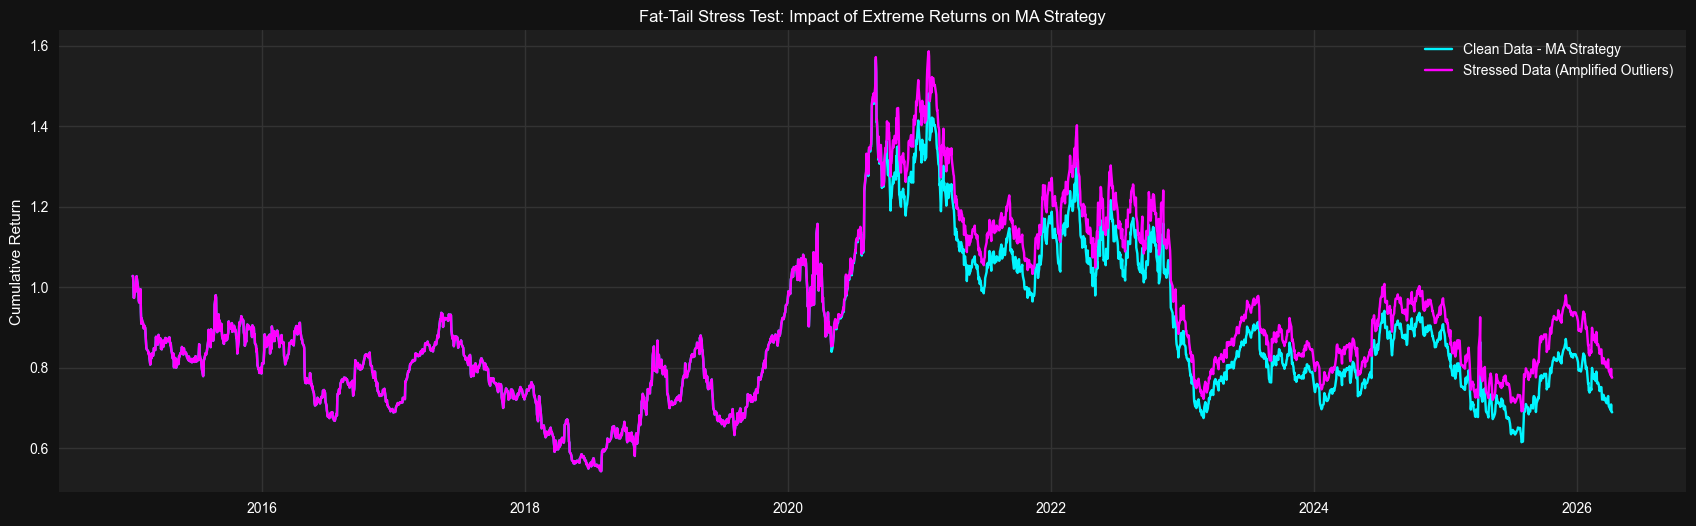

Stress test complete. Extreme outliers can significantly distort strategy equity curve.


In [45]:
def simple_ma_strategy(df: pd.DataFrame, fast: int = 20, slow: int = 50):
  """Simple moving average crossover strategy for stress testing."""
  df = df.copy()
  df['fast_ma'] = df['Adj Close'].rolling(fast).mean()
  df['slow_ma'] = df['Adj Close'].rolling(slow).mean()
  df['signal'] = np.where(df['fast_ma'] > df['slow_ma'], 1, -1)
  df['strategy_returns'] = df['returns'] * df['signal'].shift(1)
  df['cum_strategy'] = (1 + df['strategy_returns']).cumprod()
  return df

# Run on clean AAPL data
strategy_df = simple_ma_strategy(all_data["AAPL"])

# Create stressed version by amplifying top 5 extreme returns
stressed_df = all_data["AAPL"].copy()
returns = stressed_df['returns']
extreme_idx = returns.abs().nlargest(5).index
stressed_df.loc[extreme_idx, 'Adj Close'] *= 1.5   # Amplify extremes (stress test)

stressed_strategy = simple_ma_strategy(stressed_df)

# Compare cumulative performance
plt.figure(figsize=(21, 6))
plt.plot(strategy_df['cum_strategy'], label='Clean Data - MA Strategy')
plt.plot(stressed_strategy['cum_strategy'], label='Stressed Data (Amplified Outliers)')
plt.title('Fat-Tail Stress Test: Impact of Extreme Returns on MA Strategy')
plt.legend()
plt.ylabel('Cumulative Return')
plt.show()
print("Stress test complete. Extreme outliers can significantly distort strategy equity curve.")

### 6.5 Production Tip – Save Validation Report as JSON

Always version your data and validation reports. Save the multi_report dictionary as a JSON file for future reference and auditability.

In [46]:
def save_validation_report(multi_report: dict, filename: str = None):
  """Save validation results as JSON for pipeline versioning."""
  if filename is None:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"ohlcv_validation_report_{timestamp}.json"
    
    # Convert any non-serializable objects if needed
    serializable_report = {}
    for tick, rep in multi_report.items():
      serializable_report[tick] = {k: v for k, v in rep.items() if k != "metrics" or isinstance(v, (int, float))}
    
    with open(filename, 'w') as f:
      json.dump(serializable_report, f, indent=4, default=str)
    
    print(f"✅ Validation report saved to: {filename}")
    print("Tip: Commit this JSON alongside your raw data in Git / DVC for reproducible pipelines.")

# Save the multi-ticker report
save_validation_report(multi_report)

✅ Validation report saved to: ohlcv_validation_report_20260413_235210.json
Tip: Commit this JSON alongside your raw data in Git / DVC for reproducible pipelines.
